In [1]:
import os, glob
os.chdir('..')
import copper as cp
import matplotlib.pyplot as plt
lib = cp.Library(path="./copper/data/unitarydirectexpansion_curves.json")
random_seed = 1

2024-09-30 15:18:41,088 - INFO - Default fan power is based on 400 cfm/ton and 0.365 kW/cfm


## Fan Inputs

In [2]:
# Middle of the range and rounded up to the nearest tonnage
capacities = {
   "65_to_135": 96, # kBtu/h; 8 ton
   "135_to_240": 180, # kBtu/h; 15 ton
   "240_to_760": 480, # kBtu/h; 40 ton
   "gt760": 792, # kBtu/h; 66 ton
}

# See backup calcs workbooks in kW
fan_power = {
   "65_to_135": 0.524,
   "135_to_240": 1.197,
   "240_to_760": 5.243,
   "gt760": 11.190,
}

## Requirements

In [3]:
requirements = {
    "901_2004": {
        "eer": {
            "65_to_135": 10.3,
            "135_to_240": 9.7,
            "240_to_760": 9.5,
            "gt760": 9.2,
        },
        "ieer": {
            "65_to_135": None,
            "135_to_240": None,
            "240_to_760": 9.7,
            "gt760": 9.4, 
        }
    },
    "901_2022": {
        "eer": {
            "65_to_135": None,
            "135_to_240": None,
            "240_to_760": None,
            "gt760": None,
        },
        "ieer": {
            "65_to_135": 14.8,
            "135_to_240": 14.2,
            "240_to_760": 13.2,
            "gt760": 12.5, 
        }
    }
}

## Curve Generation

2024-09-30 15:19:26,297 - INFO - Target met after 41 generations.
2024-09-30 15:19:57,230 - INFO - Target met after 34 generations.
2024-09-30 15:20:38,759 - INFO - Target met after 60 generations.
2024-09-30 15:20:57,754 - INFO - Target met after 24 generations.
2024-09-30 15:21:46,322 - INFO - Target met after 70 generations.
2024-09-30 15:21:56,778 - INFO - Target met after 16 generations.


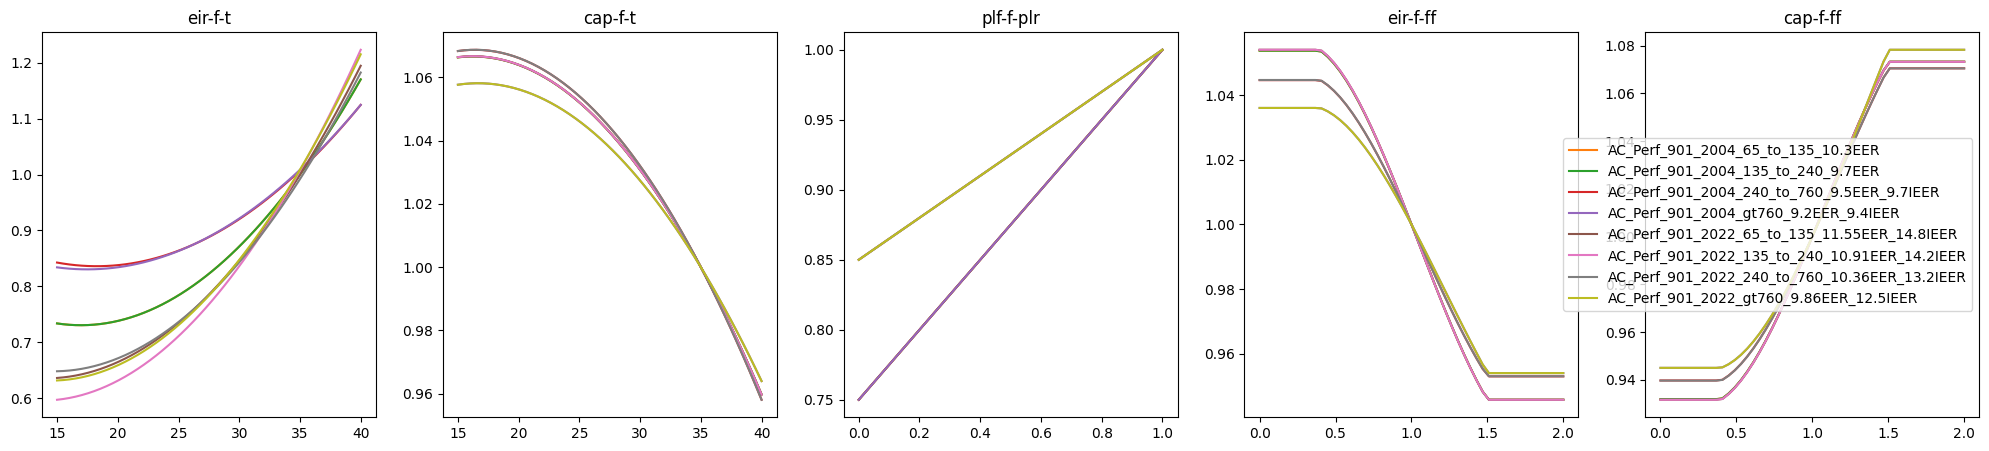

In [4]:
out_vars = ["eir-f-t", "cap-f-t", "plf-f-plr", "eir-f-ff", "cap-f-ff"]
fig, axes = plt.subplots(nrows=1, ncols=len(out_vars), figsize=(25, 5))

colors = plt.get_cmap('tab10').colors
cnt = 1

for code in list(requirements.keys()):
    for cap in list(capacities.keys()):

        if cap not in requirements[code]["ieer"].keys():
            continue

        tonnage = cp.Units(value=capacities[cap], unit="kbtu/h").conversion(new_unit="ton")

        if "2004" in code:
            if cap == "gt760":
                indoor_fan_speeds=2
            else:
                indoor_fan_speeds=1
        else:
            indoor_fan_speeds=2

        dx = cp.UnitaryDirectExpansion(
            compressor_type="scroll",
            condenser_type="air",
            compressor_speed="constant",
            ref_cap_unit="ton",
            ref_net_cap=tonnage,
            full_eff=requirements[code]["eer"][cap],
            full_eff_unit="eer",
            part_eff_ref_std="ahri_340/360",
            indoor_fan_speeds=indoor_fan_speeds,
            indoor_fan_power=fan_power[cap],
            indoor_fan_power_unit="kW",
        )

        if requirements[code]["eer"][cap] is None:
            dx.full_eff = dx.ieer_to_eer(requirements[code]["ieer"][cap])
            name = f"AC_Perf_{code}_{cap}_{round(dx.full_eff,2)}EER_{round(dx.part_eff,2)}IEER"
        
        if requirements[code]["ieer"][cap] is None:
            agg_only = True
            name = f"AC_Perf_{code}_{cap}_{round(dx.full_eff,2)}EER"
        else:
            dx.part_eff=requirements[code]["ieer"][cap]
            agg_only = False
            name = f"AC_Perf_{code}_{cap}_{round(dx.full_eff,2)}EER_{round(dx.part_eff,2)}IEER"


        if "2004" in code:
            dx.degradation_coefficient = 0.25
        else:
            dx.degradation_coefficient = 0.15
        dx.add_cycling_degradation_curve(overwrite=True)

        set_of_curves = dx.generate_set_of_curves(
                method="nearest_neighbor",
                tol=0.01,
                num_nearest_neighbors=5,
                verbose=False,
                vars=["eir-f-t"],
                random_seed=random_seed,
                agg_only=agg_only
            )
        
        dx.add_cycling_degradation_curve(overwrite=True)
        curves = cp.SetofCurves()
        curves.curves = dx.set_of_curves
        curves.eqp = dx

        limits = dx.get_ranges()
        for c in curves.curves:
            xs = limits[c.out_var]["vars_range"][0]
            c.x_min = xs[0]
            c.x_max = xs[1]
            if len(limits[c.out_var]["vars_range"]) > 1:
                ys = limits[c.out_var]["vars_range"][1]
                c.y_min = ys[0]
                c.y_max = ys[1]
            if "ff" in c.out_var:
                c.x_min = 0.4
            if "plf" in c.out_var:
                c.out_min = 0.0

        curves.export(path="./",fmt="csv",name=name)

        # Plotting space set of curves
        dx_unit_perf_curves = cp.SetofCurves()
        dx_unit_perf_curves.eqp = dx
        dx_unit_perf_curves.curves = dx.set_of_curves
        dx_unit_perf_curves.name = name
        dx_unit_perf_curves.plot(out_var=out_vars, axes=axes, color=colors[cnt], alpha=1)
        cnt += 1

    plt.legend()


In [5]:
for f in glob.glob("./AC_Perf*.idf"):
    base_idf = open("./ASHRAE901_RetailStandalone_STD2004_NewYork.idf", 'r').readlines()
    curve_set = open(f, 'r').readlines()
    curves_set_name = f.replace(".idf", "").replace(".\\","")
    new_idf = open(f"./ASHRAE901_RetailStandalone_STD2004_NewYork_{curves_set_name}.idf", "w+")
    for line in base_idf:
        if "!- Speed" in line and "SmDX" in line:
            line = line.replace("SmDX", curves_set_name).replace("CapFT", "cap-f-t").replace("CapFF", "cap-f-ff").replace("EIRFT", "eir-f-t").replace("EIRFF", "eir-f-ff").replace("PLR", "plf-f-plr")
        new_idf.write(f"{line}")
    for line in curve_set:
        new_idf.write(line)
    new_idf.close()
    #base_idf.close()

In [6]:
dx.calc_rated_eff(eff_type="part",unit="eer")

12.552368094362711

In [7]:
nf = open("./ieer_specific_curves.csv", 'w')
nf.write(f"name,variable,unit_type,curve_type,min_x,max_x,min_y,max_y,coeff1,coeff2,coeff3,coeff4,coeff5,coeff6\n")
for f in glob.glob("./AC_Perf*.csv"):
    curve_set = open(f, 'r').readlines()
    for line in curve_set:
        nf.write(line)
nf.close()